# 05 — Results & Regime Analysis

Consolidated results from the full pipeline (`run_pipeline.py`), which evaluates all seven models — including the rolling-refit GARCH(1,1) — under identical walk-forward validation.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


In [2]:
import json

results = pd.read_csv("../reports/model_results.csv")
regime_results = pd.read_csv("../reports/regime_results.csv")
with open("../reports/run_summary.json") as fh:
    summary = json.load(fh)

print(f"sample: {summary['observations_model']:,} obs, "
      f"{summary['date_start']} to {summary['date_end']}, "
      f"{summary['n_features']} features")
print(f"test period: {summary['split']['test'][0]} to {summary['split']['test'][1]} "
      f"({summary['split']['test'][2]} obs, {summary['n_walk_forward_folds']} walk-forward folds)")
results

sample: 3,957 obs, 2010-10-18 to 2026-07-14, 35 features
test period: 2024-02-29 to 2026-07-14 (594 obs, 10 walk-forward folds)


,Model,MAE,RMSE,R2,QLIKE
0,Random Forest,0.0417,0.0706,0.4109,0.3594
1,Linear Regression,0.0478,0.0759,0.3190,0.3976
2,XGBoost,0.0454,0.0785,0.2715,0.3743
3,HAR,0.0495,0.0824,0.1978,0.5150
4,"GARCH(1,1)",0.0535,0.0851,0.1438,0.4491
5,Naive (last 5d RV),0.0558,0.0940,-0.0435,0.9711
6,Naive (last 21d RV),0.0573,0.0970,-0.1109,0.5991


## Did the models beat the naive baseline?

In [3]:
best = results.iloc[0]
naive = results[results["Model"].str.startswith("Naive")].sort_values("RMSE").iloc[0]
print(f"best model:      {best['Model']}  (RMSE {best['RMSE']:.4f}, R2 {best['R2']:.3f})")
print(f"best naive:      {naive['Model']}  (RMSE {naive['RMSE']:.4f}, R2 {naive['R2']:.3f})")
print(f"RMSE reduction vs naive: {1 - best['RMSE'] / naive['RMSE']:.1%}")

best model:      Random Forest  (RMSE 0.0706, R2 0.411)
best naive:      Naive (last 5d RV)  (RMSE 0.0940, R2 -0.043)
RMSE reduction vs naive: 24.9%


## Errors by volatility regime

Regimes are terciles of trailing 21-day realized vol with breakpoints fixed on the training period. Forecast errors rise sharply in the high-vol regime for **every** model — volatility forecasting is hardest exactly when it matters most.

In [4]:
pivot = regime_results.pivot(index="Model", columns="Regime", values="RMSE")[["low", "medium", "high"]]
pivot["high / low ratio"] = pivot["high"] / pivot["low"]
pivot.sort_values("high")

Regime,low,medium,high,high / low ratio
Model,,,,
Random Forest,0.0547,0.0395,0.1087,1.9852
Linear Regression,0.0572,0.0460,0.1151,2.0133
XGBoost,0.0560,0.0402,0.1244,2.2223
HAR,0.0610,0.0469,0.1272,2.0852
"GARCH(1,1)",0.0585,0.0480,0.1330,2.2745
Naive (last 5d RV),0.0687,0.0543,0.1448,2.1081
Naive (last 21d RV),0.0655,0.0477,0.1555,2.3743


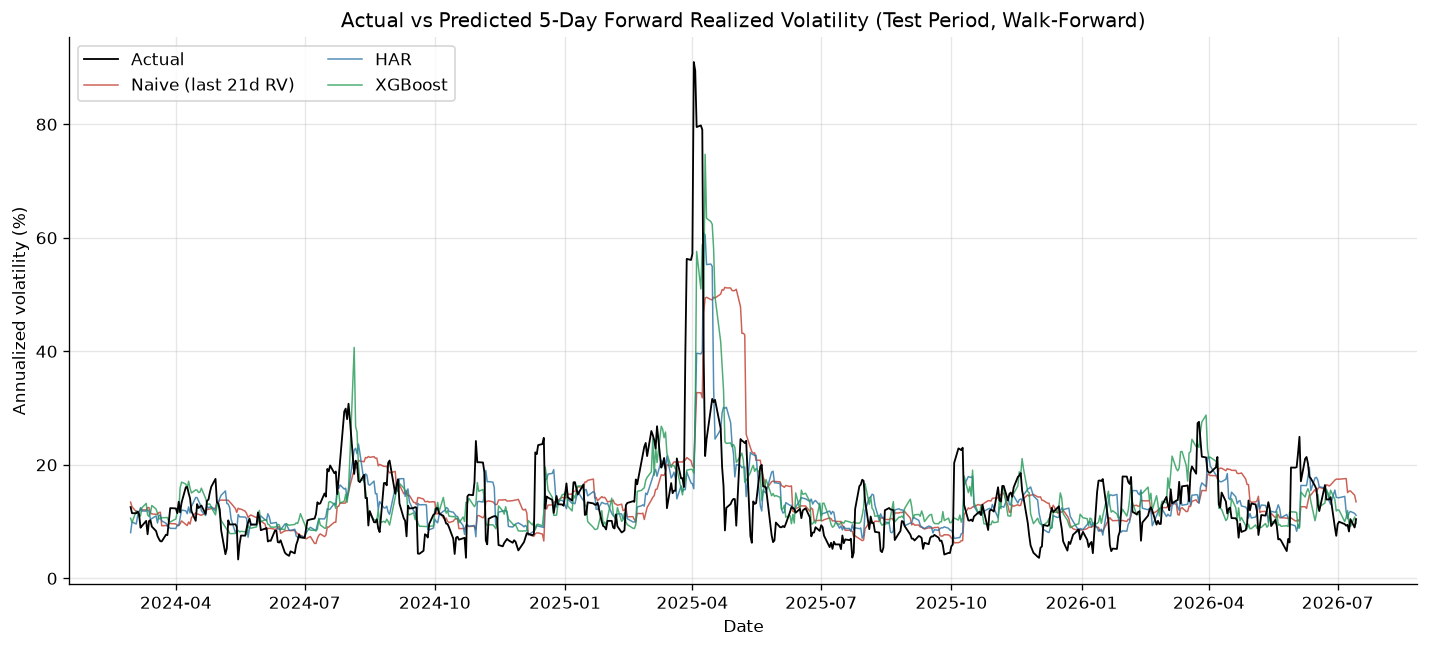

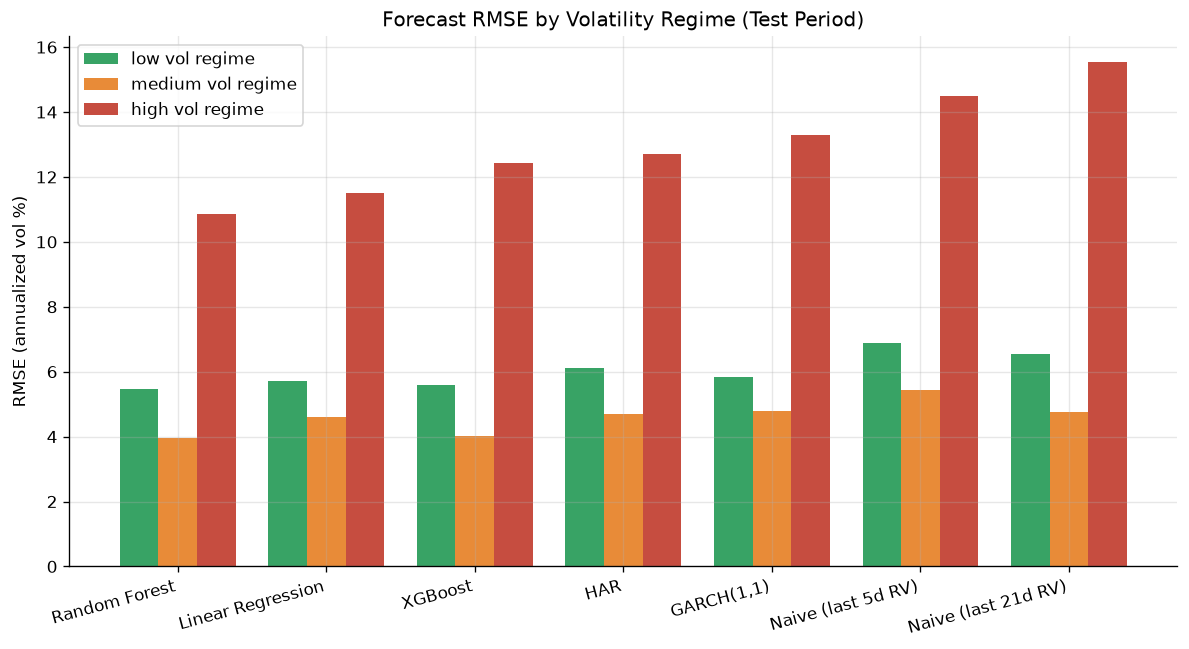

In [5]:
from IPython.display import Image, display
display(Image("../reports/figures/07_actual_vs_predicted.png"))
display(Image("../reports/figures/10_error_by_regime.png"))

## Takeaways

1. **Feature-based models beat naive persistence out-of-sample** on this test window — the naive baselines even post negative $R^2$, because trailing vol lags badly around spikes (see the 2025 vol event in the chart above: naive stays elevated after the spike has passed).
2. **Model sophistication adds little beyond the features** — the Random Forest leads, but plain OLS on the same features is competitive with (and on this window slightly better than) tuned XGBoost. Most of the predictable variation is linear persistence structure.
3. **VIX carries real incremental information**: it is the single strongest linear correlate of future realized vol and ranks high in XGBoost importance, consistent with implied vol embedding forward-looking event risk.
4. **All models degrade 2–3x in the high-vol regime** — error bars on any volatility forecast should be regime-conditional.

These takeaways restate measured outputs above; no causal claims are made.